# A)
Import dataset 'XY.csv' with 49 observations of two random variables $X$ and $Y$. Compute their Pearson correlation coefficient. Use a reshuffling technique to build an empirical distribution of their 'reshuffled correlation values' and test the hypotheses $H_0: \mbox{'no significant correlation'}$, $H_1: \mbox{'significant correlation'}$ with $0.05$ of significance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

observations = np.loadtxt('./data_ex1.6-1.7/XY.csv', delimiter=',')
X = observations[:, 0]
Y = observations[:, 1]

print(np.hstack((X[:, np.newaxis],Y[:, np.newaxis])))

[[  0.77647102  49.66584822]
 [ 52.30980607  22.09976955]
 [ 60.66987609  78.57758124]
 [ 67.89879285  99.20646551]
 [  0.72165175  12.95942319]
 [ 27.16386795  46.88532148]
 [  5.71920584  26.22995066]
 [ 12.79569057 -18.47754415]
 [ 32.51774762   5.07579056]
 [ 44.94350236   6.65211569]
 [ 37.33167875  74.28124465]
 [  0.53280471  12.82021833]
 [ 65.68652034  26.1585336 ]
 [ 27.33738648  76.46978697]
 [ 77.03498574 119.2806903 ]
 [ 59.82674708  98.76981302]
 [  3.5408334   -6.40799342]
 [ 23.92884402  30.16050089]
 [ 48.15564868   3.25923805]
 [ 18.89743269   3.88469752]
 [ 16.35245302  34.33435402]
 [ 22.30742263 -23.55088634]
 [ 14.20952747  55.23589945]
 [ 10.43586427  26.71700984]
 [ 59.52420523  14.58444662]
 [  1.81214484 -34.10455514]
 [ 61.37066693  16.19173116]
 [  4.95175269 -11.72389389]
 [ 20.87235125  61.68061193]
 [ 53.77756643  12.01456802]
 [ 29.72259547  43.75092301]
 [ 73.27968999  55.62091103]
 [ 21.94486523  45.09884841]
 [ 63.69016092  79.418701  ]
 [ 43.17773979

In [2]:
corr = np.corrcoef(X, Y)
print(corr)
corr = corr[0, 1]
print(corr)

[[1.         0.55135148]
 [0.55135148 1.        ]]
0.5513514814679973


0.025%---0.975%
[-0.2861401011913936, 0.2588697723955223]
H0 rejected


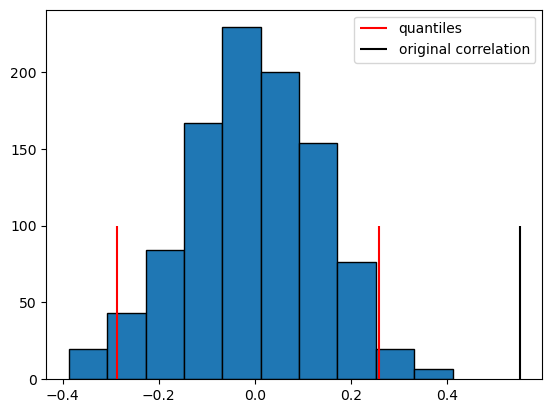

In [3]:
k = 1000
shuffle_corr = np.empty((k, 1))
for i in range(k):
    np.random.shuffle(Y)
   # print(Y)
    shuffle_corr[i, 0] = np.corrcoef(X, Y)[0, 1]
    
alpha = 0.05
alpha_half = alpha/2
q_lower, q_upper = np.quantile(shuffle_corr, [alpha_half, 1-alpha_half])

print(f'{alpha_half}%---{1-alpha_half}%')
print([q_lower,q_upper])

if corr > q_lower and corr < q_upper:
    print('H0 not rejected')
else:
    print('H0 rejected')
    
plt.hist(shuffle_corr, ec='black')
plt.vlines([q_lower,q_upper], ymin=0, ymax=100, color='r', label='quantiles')
plt.vlines(corr, ymin=0, ymax=100, color='k', label='original correlation')
plt.legend()